In [2]:
import os
import pandas as pd
import numpy as np
#%pip install databento
import databento as db
import datetime
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt

In [3]:
def process_data(daily_df):

    daily_df["weighted_mid"] = (
    daily_df["bid_px_00"] * daily_df["ask_sz_00"] + daily_df["ask_px_00"] * daily_df["bid_sz_00"]
        ) / (daily_df["bid_sz_00"] + daily_df["ask_sz_00"])

    daily_df["weighted_mid"] = daily_df["weighted_mid"].ffill()
    daily_df = daily_df.sort_index()
    daily_df = daily_df.resample("1s").ffill()

    daily_df["ret_1s"] = daily_df["weighted_mid"].pct_change()
    daily_df["ret_sq"] = daily_df["ret_1s"] ** 2

    rv_60s = daily_df["ret_sq"].resample("60s").sum()
    daily_df["rv_60s"] = rv_60s.reindex(daily_df.index, method="ffill")

    ret_1min = daily_df["weighted_mid"].resample("60s").last().pct_change()
    daily_df["ret_60s"] = ret_1min.reindex(daily_df.index, method="ffill")

    first_date = daily_df.index[0].normalize()
    session_start = first_date + pd.Timedelta(hours=8, minutes=1)
    daily_df = daily_df[daily_df.index >= session_start]
    df_1min = daily_df[daily_df.index.second == 0].copy()
    print(df_1min.shape)
    return df_1min


In [ ]:
#file = "/home/jkim/coding_projects/BernsteinMartingaleNet/MarketData/jaeyoon_test/data/arcx-pillar-20221028.bbo-1s.dbn.zst"
file = "/home/jkim/coding_projects/BernsteinMartingaleNet/MarketData/jaeyoon_test/data/arcx-pillar-20250220.bbo-1s.dbn.zst"
data = db.DBNStore.from_file(file)
jingshu_df= process_data(data.to_df()).reset_index()
date_str = file.split("-")[2].split(".")[0]
open_time = datetime.datetime.strptime(date_str + " 09:30:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
close_time = datetime.datetime.strptime(date_str + " 16:00:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
jingshu_df["ts_recv"] = pd.to_datetime(jingshu_df["ts_recv"])
jingshu_df['ts_recv_est'] = jingshu_df['ts_recv'].dt.tz_convert('America/New_York')
jingshu_df = jingshu_df[(jingshu_df["ts_recv_est"] >= open_time) & (jingshu_df["ts_recv_est"] <= close_time)]
jingshu_df["seconds_since_open"] = (jingshu_df["ts_recv_est"] - open_time).dt.total_seconds()

(959, 21)


In [30]:
df = data.to_df()
date_str = file.split("-")[2].split(".")[0]
print(date_str)
open_time = datetime.datetime.strptime(date_str + " 09:30:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
close_time = datetime.datetime.strptime(date_str + " 16:00:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
df["ts_recv"] = pd.to_datetime(df.index)
df['ts_recv_est'] = df['ts_recv'].dt.tz_convert('America/New_York')
df = df[(df["ts_recv_est"] >= open_time) & (df["ts_recv_est"] <= close_time)]
df["seconds_since_open"] = (df["ts_recv_est"] - open_time).dt.total_seconds()
df["weighted_mid"] = (
    df["bid_px_00"] * df["ask_sz_00"] + df["ask_px_00"] * df["bid_sz_00"]
    ) / (df["bid_sz_00"] + df["ask_sz_00"])
mids = np.array(df["weighted_mid"].resample("1s").ffill())

returns = (mids[60::60] - mids[:-60:60]) / mids[:-60:60]
log_prices = np.log(mids)
rv = [np.sum(np.diff(mids[60 * i: 60 * (i+1)]) / mids[60 * i: 60 * (i+1) - 1]) ** 2 for i in range(len(log_prices) // 60)]
rv = np.array(rv)

20221028


Text(0.5, 1.0, 'rv')

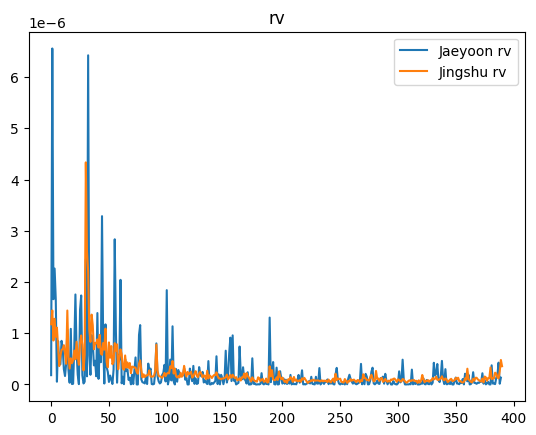

In [31]:
plt.plot(rv, label="Jaeyoon rv")
plt.plot(np.array(jingshu_df["rv_60s"]), label="Jingshu rv")
plt.legend()
plt.title("rv")

Text(0.5, 1.0, 'returns')

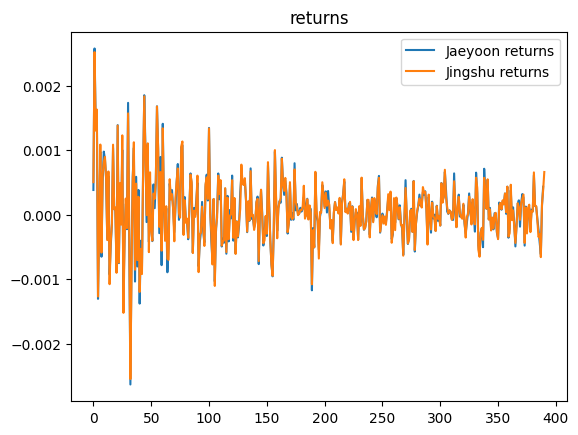

In [32]:
plt.plot(returns, label="Jaeyoon returns")
plt.plot(np.array(jingshu_df["ret_60s"]), label="Jingshu returns")
plt.legend()
plt.title("returns")